In [1]:
import json
import re
import textwrap
from statistics import mean
from pathlib import Path

import IPython.display as display
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
from pyvis.network import Network

# Paper style, as in report/paper_results.ipynb: clean whitegrid, serif fonts, muted palette.
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "axes.titleweight": "bold",
    "axes.edgecolor": "0.3",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "legend.frameon": False,
})

FIG_DIR = Path("report/figures/dataset_comparison")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Text width of a two-column paper (\textwidth for figure*/table*), in inches.
PAGE_W = 7.0
COL_W = 3.35

# Benchmark colors of the paper (TASK_STYLE in paper_results.ipynb); the light variant is a dataset's second series.
ACCENT, ACCENT_LIGHT = "#c0392b", "#e07b6f"
TRM_COLOR, TRM_LIGHT = "#2c6fbb", "#93b7e3"
KQA_COLOR, KQA_LIGHT = "#1e8c6e", "#8fc6b6"
ORANGE = "#d68910"
MUTED_LIGHT = "#b9c0c4"
DATASET_COLORS = {"MetaQA": TRM_COLOR, "KQA-Pro": KQA_COLOR, "GraphQA": ACCENT}
DATASET_LIGHT = {"MetaQA": TRM_LIGHT, "KQA-Pro": KQA_LIGHT, "GraphQA": ACCENT_LIGHT}

# Graph examples: node roles, plain edges, and the path / evidence arrows with their relation labels.
Q_NODE, A_NODE, PATH_NODE, OTHER_NODE = ACCENT, KQA_COLOR, ORANGE, MUTED_LIGHT
EDGE_COLOR, PATH_COLOR = "#cfcfcf", TRM_COLOR

# Plotly figures are laid out PLOTLY_W px wide, which becomes PAGE_W once the PDF is placed at \textwidth;
# pt() converts a font size in points to px so text matches the matplotlib figures.
PLOTLY_W = 1000
PLOTLY_FONT = "DejaVu Serif, Times New Roman, serif"


def pt(size):
    return size * PLOTLY_W / (PAGE_W * 72)


def save_fig(fig, name):
    """Export a matplotlib or Plotly figure as vector PDF and raster PNG to FIG_DIR (Plotly needs kaleido)."""
    for ext in ("pdf", "png"):
        path = FIG_DIR / f"{name}.{ext}"
        if isinstance(fig, go.Figure):
            fig.write_image(path, scale=3 if ext == "png" else 1)
        else:
            fig.savefig(path)
    return fig


def graph_layout(legend=True, top=10, height=800):
    """Paper style shared by the graph example plots: white background, serif font, no axes, legend at the bottom."""
    return dict(
        template="simple_white",
        font=dict(family=PLOTLY_FONT, size=pt(7), color="#262626"),
        showlegend=legend,
        legend=dict(orientation="h", yanchor="top", y=0, xanchor="left", x=0, font=dict(size=pt(7.5))),
        width=PLOTLY_W,
        height=height,
        margin=dict(b=40 if legend else 10, l=10, r=10, t=top),
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
    )


def qa_layout(question, answer, details=None, legend=True, wrap=95):
    """Graph layout with a Q/A title (+ small-print details line); long questions wrap to the figure width."""
    title = f"<b>Q:</b> {'<br>'.join(textwrap.wrap(question, wrap))}<br><b>A:</b> {answer}"
    if details:
        title += f"<br><span style='font-size:{pt(7):.1f}px'>{details}</span>"
    n_lines = title.count("<br>") + 1
    # Title pinned to the top edge (Plotly anchors the first line's baseline, hence one line height of padding);
    # the top margin grows with its line count.
    pad = int(pt(9)) + 10
    layout = graph_layout(legend, top=pad + int(1.3 * pt(9) * n_lines) + 25)
    layout["title"] = dict(text=title, x=0.01, xanchor="left", y=1, yref="container", yanchor="top",
                           pad=dict(t=pad), font=dict(size=pt(9)))
    return layout


def legend_entries(items):
    """Marker-only traces drawing a node-colour legend, items = [(color, label), ...]."""
    return [
        go.Scatter(x=[None], y=[None], mode="markers", name=label,
                   marker=dict(size=12, color=color, line=dict(width=1, color="white")))
        for color, label in items
    ]

In [2]:
from utils.graph_comparison import compare_graph_datasets, GraphDatasetComparison

# I. Random Accuracy Study

## 1. MetaQA

In [3]:
metaqa = json.load(open("data/metaqa/baseline/standard/test.json", "r"))
res_metaqa = json.load(open("data/results/metaqa/eval_metaqa.json", "r"))["samples"]

In [4]:
acc = sum([1 for sample in res_metaqa if sample["gold"] == sample["pred"]]) / len(metaqa)
print("Test Accuracy: " + str(round(acc*100, 2)) + "%")

Test Accuracy: 10.05%


In [5]:
r_probs = []
for sample in metaqa:
    question = sample["question"]
    # Extract potential answers from the question (entities in triples)
    pattern = r'\(\s*([^,]+?)\s*,\s*([^,]+?)\s*,\s*([^,]+?)\s*\)'
    result = re.findall(pattern, question)
    # Filter out the header (s, p, o) and extract target entities
    potential_answers = [item[2].strip() for item in result if not (item[0].strip() == 's' and item[1].strip() == 'p')]
    unique_potential_answers = list(set(potential_answers))
    random_prob = 1/len(unique_potential_answers) if unique_potential_answers else 0
    r_probs.append(random_prob)
print("Random Chance: " + str(round(mean(r_probs)*100, 2)) + "%") if r_probs else print(0)

Random Chance: 5.51%


## 2. GSM8K 

In [6]:
with open('data/results/gsm8k/eval_samples.jsonl', 'r') as json_file:
    json_list = list(json_file)

gsm = []
for json_str in json_list:
    result = json.loads(json_str)
    gsm.append(result)
print(f"Total GSM8K samples loaded: {len(gsm)}")

Total GSM8K samples loaded: 448


In [7]:
acc = sum(sample["parsed"] == sample["ground_truth"] for sample in gsm) / len(gsm) if gsm else 0
print(f"GSM8K Accuracy: {acc*100:.2f}%")

GSM8K Accuracy: 0.89%


# II. MetaQA, KQA Pro differences and similarities with GraphQA
#### Why does HRM performs better than baseline on GraphQA and MetaQA and not on KQA Pro

## 1. MetaQA

In [8]:
metaqa = json.load(open("data/metaqa/baseline/standard/test.json", "r"))
res_metaqa = json.load(open("data/results/metaqa/eval_metaqa.json", "r"))["samples"]

In [9]:
metaqa_lengths = [len(sample["question"].split()) for sample in metaqa]
metaqa_answer_lengths = [len(sample["answer"].split()) for sample in metaqa]

df_metaqa = pd.DataFrame({
    "question_length": metaqa_lengths,
    "answer_length": metaqa_answer_lengths
})

print("MetaQA question length stats:")
print("Min:", df_metaqa["question_length"].min())
print("Max:", df_metaqa["question_length"].max())
print("Average:", df_metaqa["question_length"].mean())

print("MetaQA answer length stats:")
print("Min:", df_metaqa["answer_length"].min())
print("Max:", df_metaqa["answer_length"].max())
print("Average:", df_metaqa["answer_length"].mean())

MetaQA question length stats:
Min: 46
Max: 672
Average: 484.24706867671694
MetaQA answer length stats:
Min: 1
Max: 8
Average: 1.5510887772194304


In [10]:
def extract_triples(question, pattern=None):
    if pattern is None:
        pattern = r'\(\s*([^()]+?)\s*,\s+([^()]+?)\s*,\s+([^()]+?)\s*\)'
    return re.findall(pattern, question)

def make_graph(triples):
    G = nx.DiGraph()
    for source, relation, target in triples:
        G.add_edge(source.strip(), target.strip(), label=relation.strip())
    return G

question = metaqa[0]["question"]
answer = metaqa[0]["answer"]

pattern = r'\(\s*([^()]+?)\s*,\s+([^()]+?)\s*,\s+([^()]+?)\s*\)'
triples = extract_triples(question, pattern)

G = make_graph(triples)

In [11]:
print(question)
print(answer)

In a knowledge graph, (s, p, o) means that entity s is linked to entity o by relation p.
The facts are:
(Zindagi Na Milegi Dobara, starred actors, Kalki Koechlin)
(Evil, written by, Mikael Håfström)
(Saawariya, starred actors, Salman Khan)
(The Strange Case of Angelica, directed by, Manoel de Oliveira)
(Blood for Dracula, directed by, Paul Morrissey)
(Tatie Danielle, directed by, Étienne Chatiliez)
(Tere Naam, starred actors, Salman Khan)
(Shanghai, directed by, Mikael Håfström)
(Insidious, directed by, James Wan)
(Road, Movie, release year, 2009)
(Tere Naam, written by, Bala)
(The Sure Thing, starred actors, John Cusack)
(Shanghai, release year, 2012)
(Tere Naam, directed by, Satish Kaushik)
(The Journey of Natty Gann, starred actors, John Cusack)
(Shanghai, written by, Dibakar Banerjee)
(Poltergeist III, directed by, Gary Sherman)
(The Crusades, directed by, Cecil B. DeMille)
(Must Love Dogs, starred actors, John Cusack)
(Breakfast of Champions, directed by, Alan Rudolph)
(The Number

In [12]:
# Initialize PyVis Network
net = Network(height="600px", width="100%", directed=True)

# Load your existing NetworkX graph G
net.from_nx(G)

# # Enable interactive physics GUI controls (optional)
# net.show_buttons(filter_=['physics'])

# # Save and open in your browser
# net.write_html("interactive_graph.html")

In [13]:
def plot_graph(G, answer, name=None, question=None):
    # 1. Calculate positions for the NetworkX graph
    pos = nx.spring_layout(G, seed=42)

    # 2. Extract edge positions
    edge_x = []
    edge_y = []
    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        line=dict(width=1, color=EDGE_COLOR),
        hoverinfo="none",
        mode="lines",
    )

    # 3. Extract node positions and names
    node_x = []
    node_y = []
    node_text = []
    node_colors = []
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)

        node_color = A_NODE if answer.split('.')[0] in node else OTHER_NODE
        node_colors.append(node_color)
        node_y.append(y)
        node_text.append(str(node))

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers+text",
        text=node_text,
        textposition="top center",
        hoverinfo="text",
        marker=dict(size=20, color=node_colors, line=dict(width=1, color="white")),
    )

    # 4. Create interactive Plotly figure (pan, zoom, hover), with a Q/A title when a question is given
    layout = graph_layout(legend=False)
    if question:
        layout = qa_layout(question, answer.strip().removesuffix("."), legend=False)
    fig = go.Figure(data=[edge_trace, node_trace], layout=go.Layout(hovermode="closest", **layout))

    if name:
        save_fig(fig, name)
    fig.show()

plot_graph(G, answer, name="graph_example_metaqa")

## 2. KQA Pro 

In [14]:
kqa = json.load(open("data/kqapro/baseline/standard/test.json", "r"))

In [15]:
kqa_lengths = [len(sample["question"].split()) for sample in kqa]
kqa_answer_lengths = [len(sample["answer"].split()) for sample in kqa]

df_kqa = pd.DataFrame({
    "question_length": kqa_lengths,
    "answer_length": kqa_answer_lengths
})

print("KQA question length stats:")
print("Min:", df_kqa["question_length"].min())
print("Max:", df_kqa["question_length"].max())
print("Average:", df_kqa["question_length"].mean())

print("KQA answer length stats:")
print("Min:", df_kqa["answer_length"].min())
print("Max:", df_kqa["answer_length"].max())
print("Average:", df_kqa["answer_length"].mean())

KQA question length stats:
Min: 52
Max: 1528
Average: 553.7954144620811
KQA answer length stats:
Min: 1
Max: 10
Average: 1.6657848324514992


In [16]:
kqa_question = kqa[0]["question"]
kqa_answer = kqa[0]["answer"]
kqa_triples = extract_triples(kqa_question, pattern)
kqa_G = make_graph(kqa_triples)
plot_graph(kqa_G, kqa_answer, name="graph_example_kqa")

## 3. GraphQA

In [17]:
graphqa = json.load(open("data/graphqa/baseline/standard/test.json"))

graphqa_lengths = [len(sample["question"]) for sample in graphqa]
graphqa_answer_lengths = [len(sample["answer"]) for sample in graphqa]

df_graphqa = pd.DataFrame({
    "question_length": graphqa_lengths,
    "answer_length": graphqa_answer_lengths
})

print("GraphQA question length stats:")
print("Min:", df_graphqa["question_length"].min())
print("Max:", df_graphqa["question_length"].max())
print("Average:", df_graphqa["question_length"].mean())

print("GraphQA answer length stats:")
print("Min:", df_graphqa["answer_length"].min())
print("Max:", df_graphqa["answer_length"].max())
print("Average:", df_graphqa["answer_length"].mean())

GraphQA question length stats:
Min: 223
Max: 1650
Average: 472.1974025974026
GraphQA answer length stats:
Min: 2
Max: 54
Average: 7.301298701298701


In [18]:
question

"In a knowledge graph, (s, p, o) means that entity s is linked to entity o by relation p.\nThe facts are:\n(Zindagi Na Milegi Dobara, starred actors, Kalki Koechlin)\n(Evil, written by, Mikael Håfström)\n(Saawariya, starred actors, Salman Khan)\n(The Strange Case of Angelica, directed by, Manoel de Oliveira)\n(Blood for Dracula, directed by, Paul Morrissey)\n(Tatie Danielle, directed by, Étienne Chatiliez)\n(Tere Naam, starred actors, Salman Khan)\n(Shanghai, directed by, Mikael Håfström)\n(Insidious, directed by, James Wan)\n(Road, Movie, release year, 2009)\n(Tere Naam, written by, Bala)\n(The Sure Thing, starred actors, John Cusack)\n(Shanghai, release year, 2012)\n(Tere Naam, directed by, Satish Kaushik)\n(The Journey of Natty Gann, starred actors, John Cusack)\n(Shanghai, written by, Dibakar Banerjee)\n(Poltergeist III, directed by, Gary Sherman)\n(The Crusades, directed by, Cecil B. DeMille)\n(Must Love Dogs, starred actors, John Cusack)\n(Breakfast of Champions, directed by, Ala

In [19]:
graphqa_question = graphqa[0]["question"]
graphqa_answer = graphqa[0]["answer"]

graphqa_pattern = r'\(\s*(\d+)\s*,\s*(\d+)\s*\)'

def make_graph_from_couples(couples):
    G = nx.Graph()
    for u, v in couples:
        G.add_edge(u, v)
    return G

graphqa_couples = extract_triples(graphqa_question, graphqa_pattern)
graphqa_G = make_graph_from_couples(graphqa_couples)
plot_graph(graphqa_G, graphqa_answer, name="graph_example_graphqa",
           question=graphqa_question.split("Q:")[-1].split("\n")[0].strip())

## 4. Summary

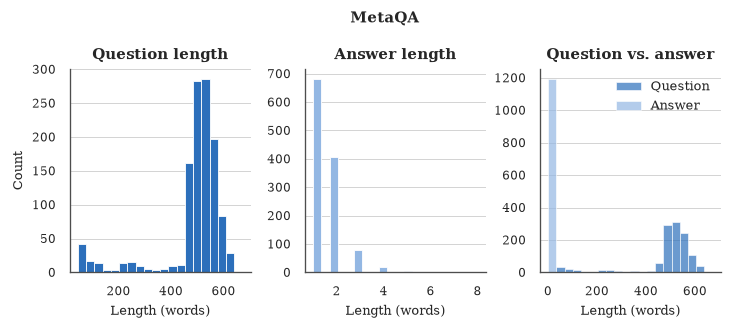

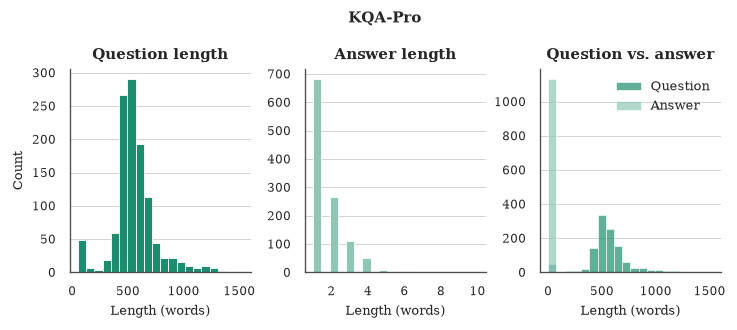

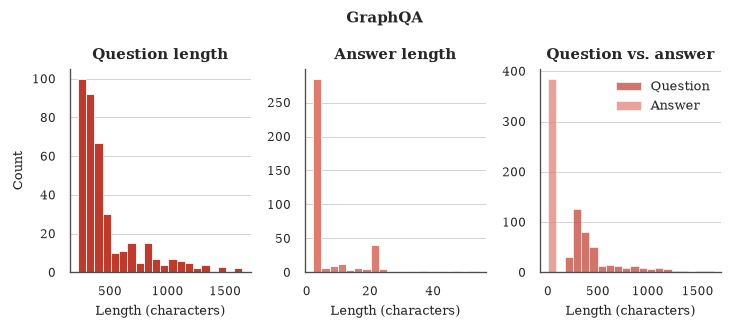

In [20]:
datasets = {
    "MetaQA": df_metaqa,
    "KQA-Pro": df_kqa,
    "GraphQA": df_graphqa
}
# MetaQA and KQA-Pro lengths are word counts, GraphQA's are character counts (see above).
LENGTH_UNIT = {"MetaQA": "words", "KQA-Pro": "words", "GraphQA": "characters"}

for dataset_name, df in datasets.items():
    color, light = DATASET_COLORS[dataset_name], DATASET_LIGHT[dataset_name]
    fig, axes = plt.subplots(1, 3, figsize=(PAGE_W, 2.2), gridspec_kw={"wspace": 0.3})
    bar = dict(edgecolor="white", linewidth=0.5)

    axes[0].hist(df["question_length"], bins=20, color=color, **bar)
    axes[0].set_title("Question length", fontsize=9)

    axes[1].hist(df["answer_length"], bins=20, color=light, **bar)
    axes[1].set_title("Answer length", fontsize=9)

    # Overlay on shared bin edges, so the two histograms are directly comparable.
    edges = np.histogram_bin_edges(pd.concat([df["question_length"], df["answer_length"]]), bins=20)
    axes[2].hist(df["question_length"], bins=edges, color=color, alpha=0.7, label="Question", **bar)
    axes[2].hist(df["answer_length"], bins=edges, color=light, alpha=0.7, label="Answer", **bar)
    axes[2].set_title("Question vs. answer", fontsize=9)
    axes[2].legend(fontsize=7.5)

    for ax in axes:
        ax.set_xlabel(f"Length ({LENGTH_UNIT[dataset_name]})", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(axis="x", visible=False)
    axes[0].set_ylabel("Count", fontsize=8)
    fig.suptitle(dataset_name, fontsize=9, fontweight="bold", y=1.1)
    sns.despine(fig=fig)
    save_fig(fig, f"lengths_{dataset_name.split('-')[0].lower()}")
    plt.show()

## 5. Statistical Comparison

In [21]:
mqa_graphs = []
kqa_graphs = []
graphqa_graphs = []

for sample_metaqa, sample_kqa, sample_graphqa in zip(metaqa, kqa, graphqa):
    mqa_question = sample_metaqa["question"]
    mqa_answer = sample_metaqa["answer"]
    mqa_triples = extract_triples(mqa_question, pattern)
    mqa_G = make_graph(mqa_triples)
    mqa_graphs.append(mqa_G)

    kqa_question = sample_kqa["question"]
    kqa_answer = sample_kqa["answer"]
    kqa_triples = extract_triples(kqa_question, pattern)
    kqa_G = make_graph(kqa_triples)
    kqa_graphs.append(kqa_G)

    graphqa_question = sample_graphqa["question"]
    graphqa_answer = sample_graphqa["answer"]
    graphqa_couples = extract_triples(graphqa_question, graphqa_pattern)
    graphqa_G = make_graph_from_couples(graphqa_couples)
    graphqa_graphs.append(graphqa_G)


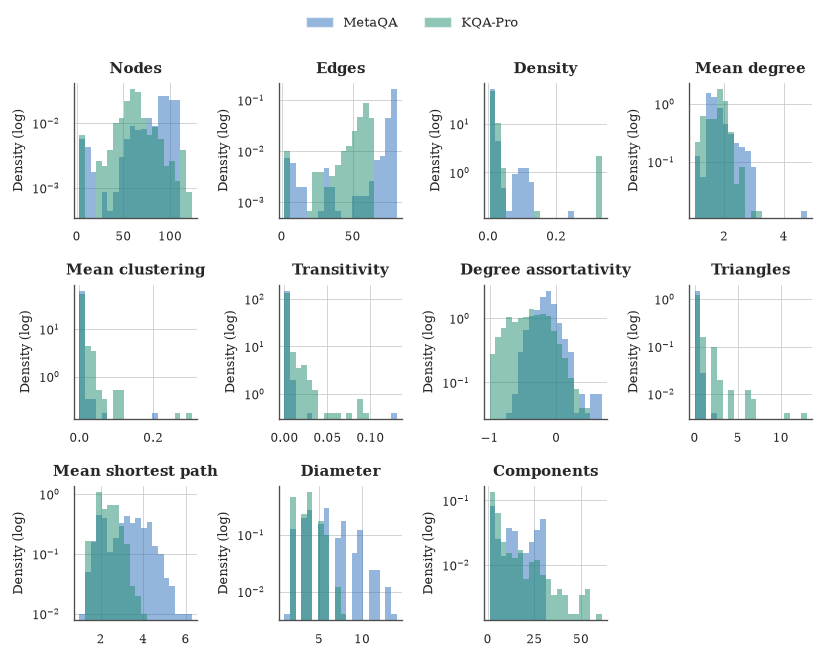

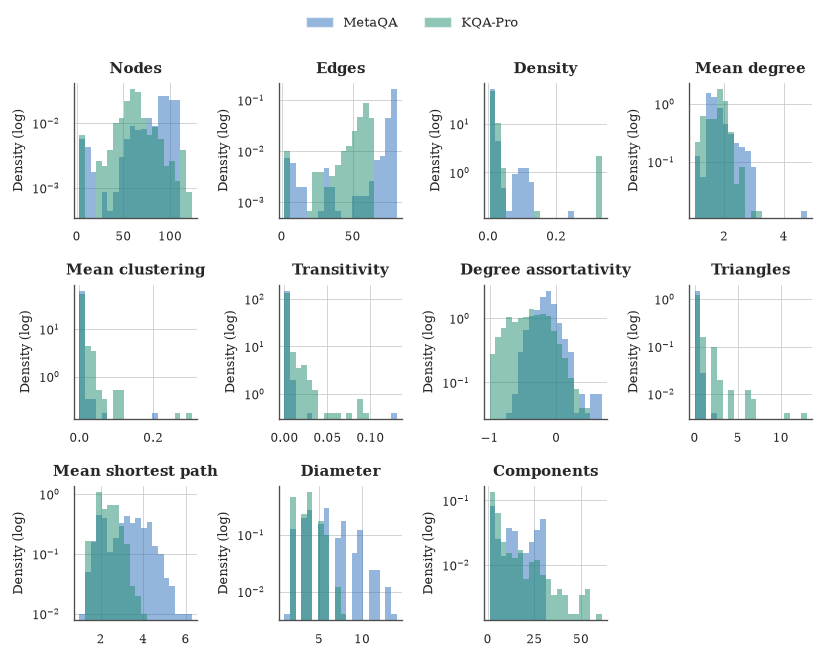

In [22]:
# Display names of the structural statistics (utils/graph_comparison.py STAT_FUNCS), in plotting order.
STAT_LABELS = {
    "num_nodes": "Nodes",
    "num_edges": "Edges",
    "density": "Density",
    "avg_degree": "Mean degree",
    "avg_clustering": "Mean clustering",
    "transitivity": "Transitivity",
    "assortativity": "Degree assortativity",
    "num_triangles": "Triangles",
    "avg_shortest_path": "Mean shortest path",
    "diameter": "Diameter",
    "num_components": "Components",
}
GRAPH_STATS_PLOT = dict(colors=DATASET_COLORS, stat_labels=STAT_LABELS, ncols=4, figsize=(PAGE_W, 5.2))

res_mqa_kqa = compare_graph_datasets(mqa_graphs, kqa_graphs, label_a="MetaQA", label_b="KQA-Pro",
                                     plot_kwargs=GRAPH_STATS_PLOT)
save_fig(res_mqa_kqa["figure"], "graph_stats_metaqa_vs_kqa")

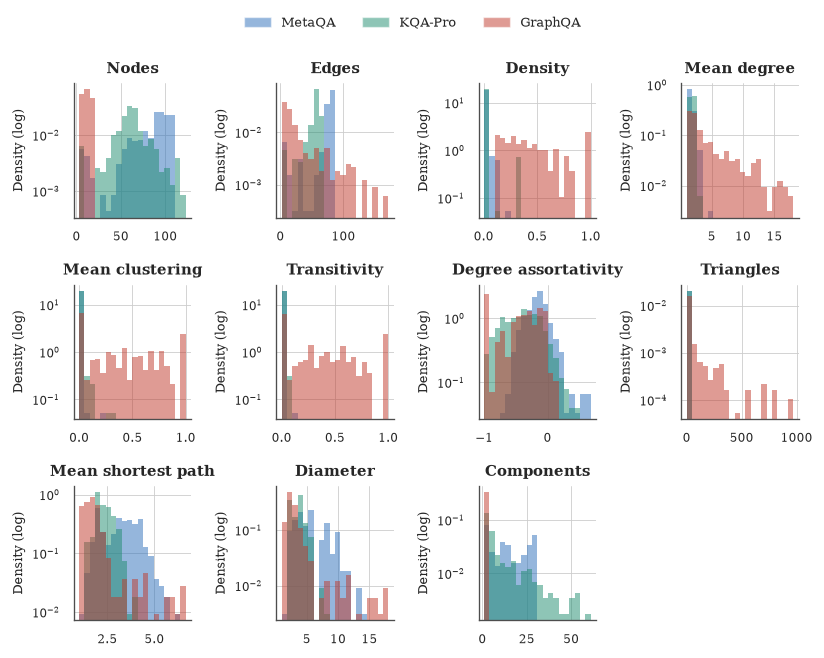

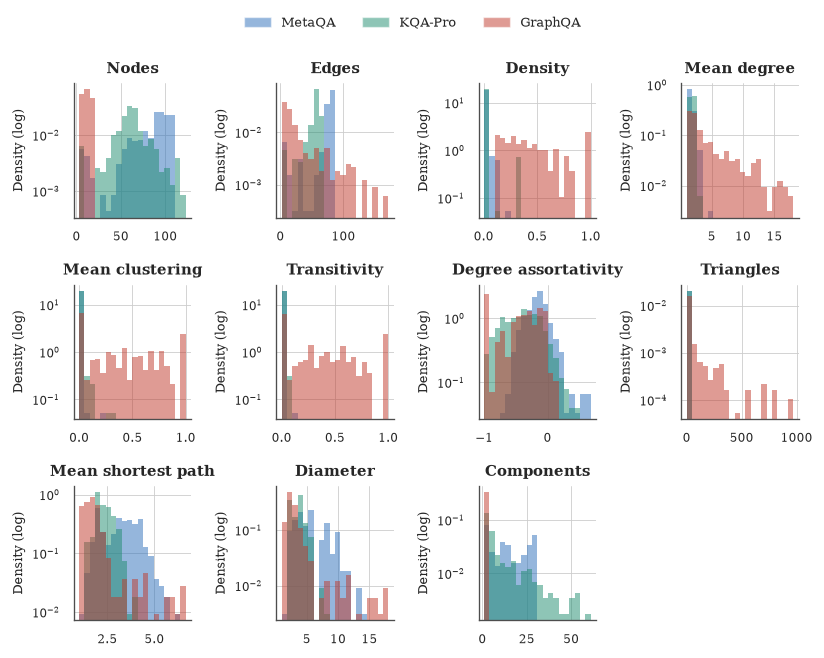

In [23]:
comp = GraphDatasetComparison(
    {
        "MetaQA": mqa_graphs,
        "KQA-Pro": kqa_graphs,
        "GraphQA": graphqa_graphs,
    }
)

results = comp.compare(run_mmd=True, plot_kwargs=GRAPH_STATS_PLOT)
save_fig(results["figure"], "graph_stats_all")

In [24]:
results["mmd_matrix"]

,MetaQA,KQA-Pro,GraphQA
MetaQA,0.000000,0.087319,0.317424
KQA-Pro,0.087319,0.000000,0.474328
GraphQA,0.317424,0.474328,0.000000


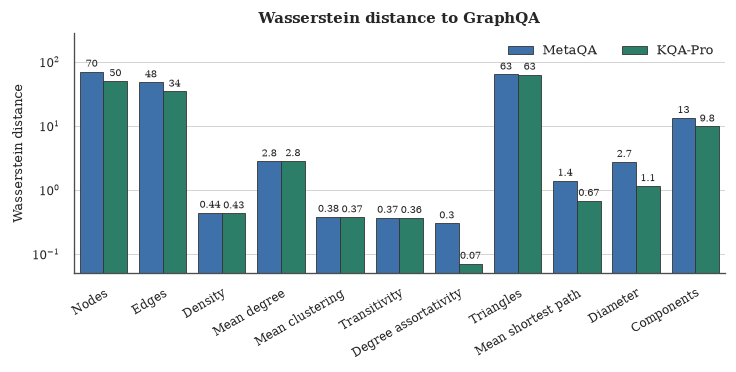

In [25]:
df_filtered = results["pairwise_tests"][
    (results["pairwise_tests"]["dataset_b"] == "GraphQA") &
    (results["pairwise_tests"]["dataset_a"].isin(["MetaQA", "KQA-Pro"]))
].assign(statistic=lambda d: d["statistic"].map(STAT_LABELS))

# Full-width `figure*`: one bar pair per statistic.
order = [s for s in STAT_LABELS.values() if s in set(df_filtered["statistic"])]
fig, ax = plt.subplots(figsize=(PAGE_W, 2.6))
sns.barplot(
    data=df_filtered,
    x="statistic",
    y="wasserstein_distance",
    hue="dataset_a",
    order=order,
    hue_order=["MetaQA", "KQA-Pro"],
    palette=DATASET_COLORS,
    edgecolor="0.2",
    linewidth=0.5,
    ax=ax,
)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.2g", padding=1.5, fontsize=6)

# Each distance is in its statistic's own units, so they can span orders of magnitude.
dist = df_filtered["wasserstein_distance"]
if dist[dist > 0].max() / dist[dist > 0].min() > 100:
    ax.set_yscale("log")
    ax.set_ylim(top=dist.max() * 4)  # headroom for the value labels and the legend
ax.set_xticks(range(len(order)), order, rotation=30, ha="right", rotation_mode="anchor", fontsize=7)
ax.set_xlabel("")
ax.set_ylabel("Wasserstein distance", fontsize=8)
ax.set_title("Wasserstein distance to GraphQA", fontsize=9)
ax.tick_params(axis="y", labelsize=7)
ax.grid(axis="x", visible=False)
ax.legend(title="", fontsize=7.5, ncol=2, loc="upper right")
sns.despine(ax=ax)
save_fig(fig, "wasserstein_to_graphqa")
plt.show()

## 6. Graph Path and Question/Answer Study

How does question and answer connect in MetaQA (not sure the same is possible for KQA Pro)

In [26]:
paths = [
    "data/metaqa/1-hop/vanilla/qa_dev.txt",
    "data/metaqa/2-hop/vanilla/qa_dev.txt",
    "data/metaqa/3-hop/vanilla/qa_dev.txt",
    "data/metaqa/1-hop/vanilla/qa_test.txt",
    "data/metaqa/2-hop/vanilla/qa_test.txt",
    "data/metaqa/3-hop/vanilla/qa_test.txt",
    "data/metaqa/1-hop/vanilla/qa_train.txt",
    "data/metaqa/2-hop/vanilla/qa_train.txt",
    "data/metaqa/3-hop/vanilla/qa_train.txt",
]
original_metaqa = []
for path in paths:
    with open(path, "r") as f:
        data = f.read().splitlines()
    original_metaqa.extend(data)



In [27]:
clean_omqa = []
for item in original_metaqa:
    clean_omqa.append({"question": item.split('\t')[0], 
                       "answers": item.split('\t')[1].split("|")})

clean_omqa[0]

{'question': 'what movies did [Temuera Morrison] act in',
 'answers': ['Once Were Warriors', 'Tracker', 'River Queen']}

In [28]:
mqa_question = metaqa[3]["question"].split("Q:")[1].split("\n")[0].strip()
mqa_answer = metaqa[3]["answer"]
mqa_question, mqa_answer

('who is listed as director for Poltergeist', 'Tobe Hooper.')

In [29]:
for item in clean_omqa:
    if mqa_question in item["question"].replace("[", "").replace("]", ""):
        print(item)
        q_entity = re.findall(r'\[(.*?)\]', item["question"])[0]
        a_entity = item["answers"][0]
q_entity, a_entity

{'question': 'who is listed as director for [Poltergeist]', 'answers': ['Tobe Hooper']}


('Poltergeist', 'Tobe Hooper')

In [30]:
def plot_graph2(G, question, answer, name=None, question_text=None, answer_text=None):
    # 1. Calculate positions for the NetworkX graph
    pos = nx.spring_layout(G, seed=42)

    # Extract question and answer entities
    q_entity = question.split('.')[0]
    a_entity = answer.split('.')[0]
    
    # Find shortest path between question and answer entities
    # (follow fact direction first, else allow hops against it)
    shortest_path = None
    for graph in (G, G.to_undirected(as_view=True)):
        try:
            shortest_path = nx.shortest_path(graph, source=q_entity, target=a_entity)
            break
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            pass
    path_nodes = set(shortest_path or [])
    
    # Create set of edges in the shortest path for quick lookup
    path_edges = set()
    if shortest_path:
        for i in range(len(shortest_path) - 1):
            edge = (shortest_path[i], shortest_path[i + 1])
            reverse_edge = (shortest_path[i + 1], shortest_path[i])
            path_edges.add(edge)
            path_edges.add(reverse_edge)

    # 2. Extract regular edge positions (non-path edges)
    edge_x = []
    edge_y = []
    for edge in G.edges():
        if edge not in path_edges and (edge[1], edge[0]) not in path_edges:
            x0, y0 = pos[edge[0]]
            x1, y1 = pos[edge[1]]
            edge_x.extend([x0, x1, None])
            edge_y.extend([y0, y1, None])

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        line=dict(width=1, color=EDGE_COLOR),
        hoverinfo="none",
        mode="lines",
        showlegend=False,
    )
    
    # 2b. Shortest path as arrows from question to answer, labelled with the relation
    #     (⁻¹ when the hop goes against the fact's direction)
    annotations = []
    label_x = []
    label_y = []
    label_text = []
    path_str = q_entity if shortest_path else "no path between question and answer entities"
    if shortest_path:
        for u, v in zip(shortest_path, shortest_path[1:]):
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            annotations.append(dict(
                x=x1, y=y1, ax=x0, ay=y0, xref="x", yref="y", axref="x", ayref="y",
                showarrow=True, arrowhead=2, arrowsize=1.2, arrowwidth=3, arrowcolor=PATH_COLOR,
                standoff=11, startstandoff=11,
            ))
            label_x.append((x0 + x1) / 2)
            label_y.append((y0 + y1) / 2)
            label_text.append(G.edges[u, v]["label"] if G.has_edge(u, v) else G.edges[v, u]["label"] + "⁻¹")
            path_str += f" —{label_text[-1]}→ {v}"

    label_trace = go.Scatter(
        x=label_x,
        y=label_y,
        mode="text",
        text=label_text,
        textfont=dict(color=PATH_COLOR, size=pt(7)),
        hoverinfo="none",
        showlegend=False,
    )

    # 3. Extract node positions and names
    node_x = []
    node_y = []
    node_text = []
    node_colors = []
    node_labels = []
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        if q_entity in node:
            node_colors.append(Q_NODE)
        elif a_entity in node:
            node_colors.append(A_NODE)
        elif node in path_nodes:
            node_colors.append(PATH_NODE)
        else:
            node_colors.append(OTHER_NODE)
        node_y.append(y)
        # Path nodes get an opaque label on top, so hubs do not hide them
        node_text.append("" if node in path_nodes else str(node))
        if node in path_nodes:
            node_labels.append(dict(x=x, y=y, text=f"<b>{node}</b>", showarrow=False, yshift=17,
                                    bgcolor="rgba(255,255,255,0.85)", font=dict(size=pt(7.5))))

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers+text",
        text=node_text,
        textposition="top center",
        hoverinfo="text",
        marker=dict(size=20, color=node_colors, line=dict(width=1, color="white")),
        showlegend=False,
    )

    legend = legend_entries([(Q_NODE, "question entity"), (A_NODE, "answer"),
                             (PATH_NODE, "on path"), (OTHER_NODE, "other")])

    # 4. Create interactive Plotly figure (pan, zoom, hover): question, answer and path as title
    fig = go.Figure(
        data=[edge_trace, node_trace, label_trace, *legend],
        layout=go.Layout(
            hovermode="closest",
            annotations=node_labels + annotations,  # arrows drawn over labels
            **qa_layout(question_text or q_entity, answer_text or a_entity, details=path_str),
        ),
    )

    if name:
        save_fig(fig, name)
    fig.show()

In [31]:
triples = extract_triples(metaqa[3]["question"], pattern)
G = make_graph(triples)
plot_graph2(G, q_entity, a_entity, name="graph_example_metaqa_path",
            question_text=mqa_question, answer_text=mqa_answer.strip().removesuffix("."))

### KQA Pro: KoPL-traced evidence
KQA Pro answers are often not graph nodes (relation labels, qualifier values, counts, yes/no), so a question→answer shortest path misses the reasoning. Instead, the question's KoPL program (from `data/kqapro/original/val.json`) is run on the prompt facts and every fact it uses is highlighted (`utils/kopl_trace.py`).

Red: `Find` entities · green: answer node · orange: other entities the program uses · blue arrows: facts used by the program, labelled with their relation.

In [32]:
from utils.kopl_trace import parse_facts, trace_kopl

kqa_original = {s["question"].strip(): s for s in json.load(open("data/kqapro/original/val.json"))}


def kqa_kopl_trace(sample):
    """Run the KoPL program of a KQA test sample over the facts in its prompt."""
    question = sample["question"].split("Q:")[-1].split("\n")[0].strip()
    original = kqa_original[question]
    facts = parse_facts(sample["question"])
    return question, facts, trace_kopl(original["program"], facts, original["answer"])

In [33]:
def plot_kopl_trace(G, question, trace, name=None):
    # 1. Calculate positions for the NetworkX graph
    pos = nx.spring_layout(G, seed=42)

    evidence = {}
    for f in trace["evidence"]:
        evidence.setdefault((f.s, f.o), []).append(f.p)
    q_entities = set(trace["question_entities"])
    a_entity = trace["answer"] if trace["answer_kind"] == "node" else None
    used = {n for edge in evidence for n in edge}

    # 2. Edges not used by the program
    edge_x = []
    edge_y = []
    for u, v in G.edges():
        if (u, v) not in evidence:
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            edge_x.extend([x0, x1, None])
            edge_y.extend([y0, y1, None])

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        line=dict(width=1, color=EDGE_COLOR),
        hoverinfo="none",
        mode="lines",
        showlegend=False,
    )

    # 2b. Facts used by the program: arrows s -> o labelled with the relation
    arrows = []
    label_x = []
    label_y = []
    label_text = []
    for (u, v), relations in evidence.items():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        if u != v:
            arrows.append(dict(
                x=x1, y=y1, ax=x0, ay=y0, xref="x", yref="y", axref="x", ayref="y",
                showarrow=True, arrowhead=2, arrowsize=1.2, arrowwidth=3, arrowcolor=PATH_COLOR,
                standoff=11, startstandoff=11,
            ))
        label_x.append((x0 + x1) / 2)
        label_y.append((y0 + y1) / 2 - (0.06 if u == v else 0))  # self-loop facts: label under the node
        label_text.append(" / ".join(relations))

    label_trace = go.Scatter(
        x=label_x,
        y=label_y,
        mode="text",
        text=label_text,
        textfont=dict(color=PATH_COLOR, size=pt(7)),
        hoverinfo="none",
        showlegend=False,
    )

    # 3. Extract node positions and names
    node_x = []
    node_y = []
    node_text = []
    node_colors = []
    node_labels = []
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
        # Nodes used by the program get an opaque label on top, so hubs do not hide them
        node_text.append("" if node in used | q_entities else str(node))
        if node in used | q_entities:
            node_labels.append(dict(x=x, y=y, text=f"<b>{node}</b>", showarrow=False, yshift=17,
                                    bgcolor="rgba(255,255,255,0.85)", font=dict(size=pt(7.5))))
        if node in q_entities:
            node_colors.append(Q_NODE)
        elif node == a_entity:
            node_colors.append(A_NODE)
        elif node in used:
            node_colors.append(PATH_NODE)
        else:
            node_colors.append(OTHER_NODE)

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers+text",
        text=node_text,
        textposition="top center",
        hoverinfo="text",
        marker=dict(size=20, color=node_colors, line=dict(width=1, color="white")),
        showlegend=False,
    )

    legend = legend_entries([(Q_NODE, "Find entity"), (A_NODE, "answer"),
                             (PATH_NODE, "used by program"), (OTHER_NODE, "other")])

    # 4. Title: question, answer (and where it comes from), KoPL program
    answer = trace["answer"]
    if trace["answer_kind"] != "node":
        answer = f'{answer} <i>({trace["answer_detail"]})</i>'
    steps = trace["program_str"].split(" → ")
    program = "<br>".join(" → ".join(steps[i:i + 4]) for i in range(0, len(steps), 4))

    fig = go.Figure(
        data=[edge_trace, node_trace, label_trace, *legend],
        layout=go.Layout(
            hovermode="closest",
            annotations=node_labels + arrows,  # arrows drawn over labels
            **qa_layout(question, answer, details=program),
        ),
    )

    if name:
        save_fig(fig, name)
    fig.show()

In [34]:
KQA_EXAMPLE = 83  # Multihop: FindAll + FilterStr, backward and forward Relate, And

kopl_question, kopl_facts, kopl_trace = kqa_kopl_trace(kqa[KQA_EXAMPLE])
print(kopl_question, "->", kopl_trace["answer"], f'[{kopl_trace["answer_kind"]}: {kopl_trace["answer_detail"]}]')
print(kopl_trace["program_str"])
for f in kopl_trace["evidence"]:
    print("  ", f)

kopl_G = make_graph([(f.s, f.p, f.o) for f in kopl_facts])
plot_kopl_trace(kopl_G, kopl_question, kopl_trace, name="graph_example_kqa_kopl")

Which town's native label is Doncaster and is the birthplace of Jack White (the one that died in Royal Tunbridge Wells) ? -> Doncaster [node: graph node]
FindAll() → FilterStr(native label, Doncaster) → FilterConcept(town) → Find(Royal Tunbridge Wells) → Relate(place of death, backward) → Find(Jack White) → And() → Relate(place of birth, forward) → FilterConcept(town) → And() → What()
   Fact(s='Doncaster', p='instance of', o='town', quals=())
   Fact(s='Doncaster', p='native label', o='Doncaster', quals=())
   Fact(s='Jack White', p='place of birth', o='Doncaster', quals=())
   Fact(s='Jack White', p='place of death', o='Royal Tunbridge Wells', quals=())
